In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [11]:
dfp= pd.read_csv(r'C:\Users\noura\ml-disaster-survival-project\data\processed\disaster_ml_dataset.csv')

In [12]:
# Ordonner certaines catégories pour des plots plus lisibles
age_order = ["Child", "Teen", "YoungAdult", "Adult", "Senior"]
if "age_group" in dfp.columns:
    dfp["age_group"] = pd.Categorical(dfp["age_group"], categories=age_order, ordered=True)


In [13]:
travel_order = ["First", "Second", "Third", "Passenger", "Crew"]
if "travel_class" in dfp.columns:
    dfp["travel_class"] = pd.Categorical(dfp["travel_class"], categories=travel_order, ordered=True)

In [ ]:
travel_order = ["First", "Second", "Third", "Passenger", "Crew"]
if "travel_class" in dfp.columns:
    dfp["travel_class"] = pd.Categorical(dfp["travel_class"], categories=travel_order, ordered=True)

In [17]:
def bar_with_labels(x, y, title="", xlabel="", ylabel="", ylim=(0,1)):
    plt.figure(figsize=(9,5))
    bars = plt.bar(x, y)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    if ylim is not None:
        plt.ylim(*ylim)
    for b in bars:
        h = b.get_height()
        if np.isfinite(h):
            plt.text(b.get_x() + b.get_width()/2, h + (0.02 if ylim else 0), f"{h:.2f}",
                     ha="center", va="bottom")
    plt.show()

### Taux de survie par catastrophe

Cette figure compare le taux global de survie pour chacune des trois catastrophes maritimes. Comme la variable *Survived* est binaire (0/1), sa moyenne correspond directement à la probabilité de survie. Les différences observées reflètent les conditions structurelles et historiques propres à chaque événement, notamment l’époque, les protocoles d’évacuation et le contexte (par exemple la guerre ou les conditions météorologiques).

,n,survival_rate
disaster,,
Lusitania,1964,0.391548
Estonia,989,0.138524
Titanic,887,0.385569


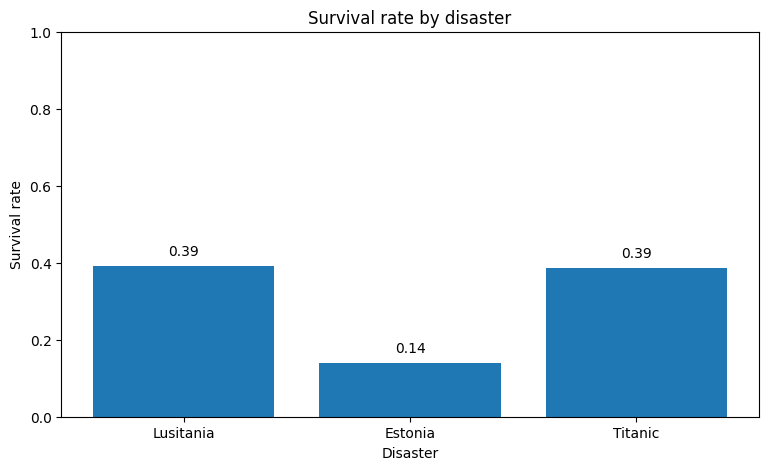

In [18]:
# 1) Overview: taille + taux de survie par catastrophe
# Explication: la moyenne de Survived (0/1) = taux de survie.
# =========================
overview = (
    dfp.groupby("disaster")
       .agg(n=("Survived","size"), survival_rate=("Survived","mean"))
       .sort_values("n", ascending=False)
)
display(overview)

bar_with_labels(
    overview.index.astype(str),
    overview["survival_rate"].values,
    title="Survival rate by disaster",
    xlabel="Disaster",
    ylabel="Survival rate"
)


### Taux de survie par sexe

Cette figure illustre la probabilité de survie selon le sexe au sein de chaque catastrophe. Historiquement, la règle implicite « femmes et enfants d’abord » a souvent influencé les procédures d’évacuation, notamment au début du XXe siècle. Les écarts observés permettent d’évaluer dans quelle mesure cette norme sociale a été appliquée dans chaque contexte.

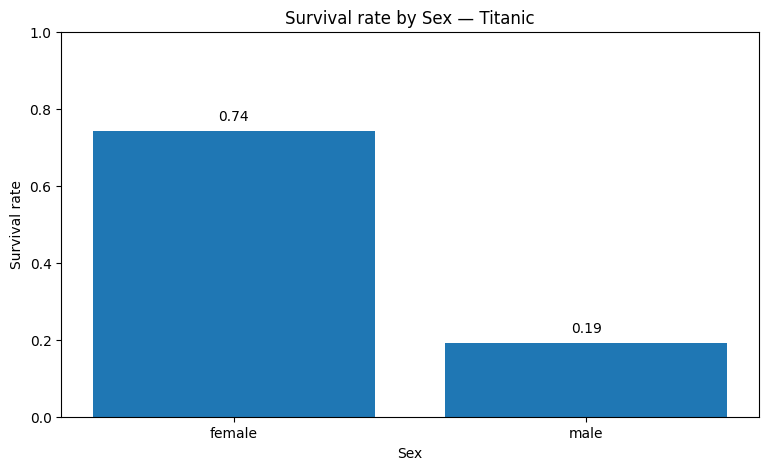

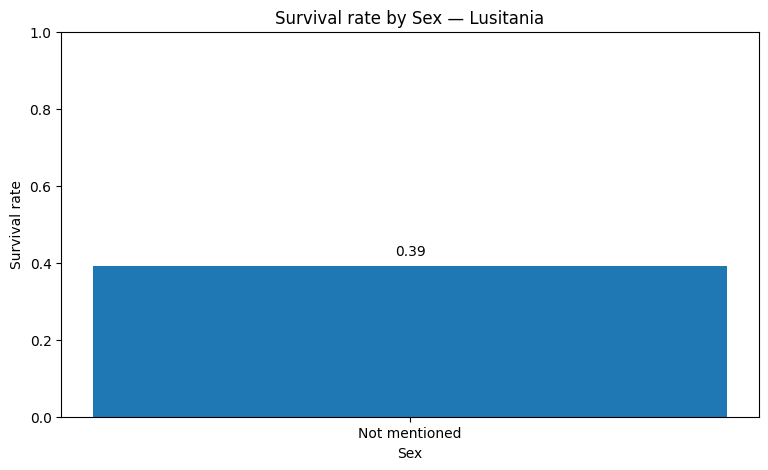

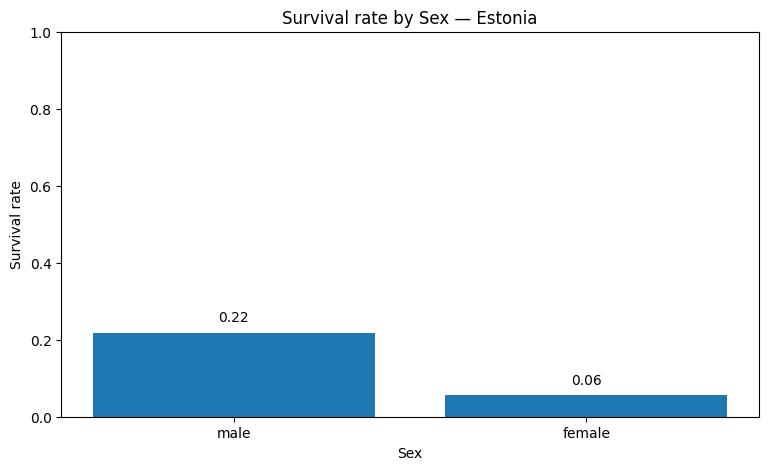

In [19]:
# 2) Sex -> Survived (par catastrophe)
# Explication: on compare la survie selon le sexe à l'intérieur de chaque catastrophe.
# =========================
for dis in dfp["disaster"].unique():
    tmp = (
        dfp[dfp["disaster"] == dis]
        .groupby("Sex")["Survived"]
        .mean()
        .sort_values(ascending=False)
    )
    bar_with_labels(
        tmp.index.astype(str),
        tmp.values,
        title=f"Survival rate by Sex — {dis}",
        xlabel="Sex",
        ylabel="Survival rate"
    )


### Taux de survie par classe de voyage

Ce graphique analyse la relation entre la classe de voyage (ou le statut d’équipage) et la survie. La hiérarchie sociale et la localisation à bord du navire ont probablement joué un rôle majeur dans l’accès aux canots de sauvetage. Cette figure permet d’évaluer si le statut socio-économique a systématiquement influencé les chances de survie.

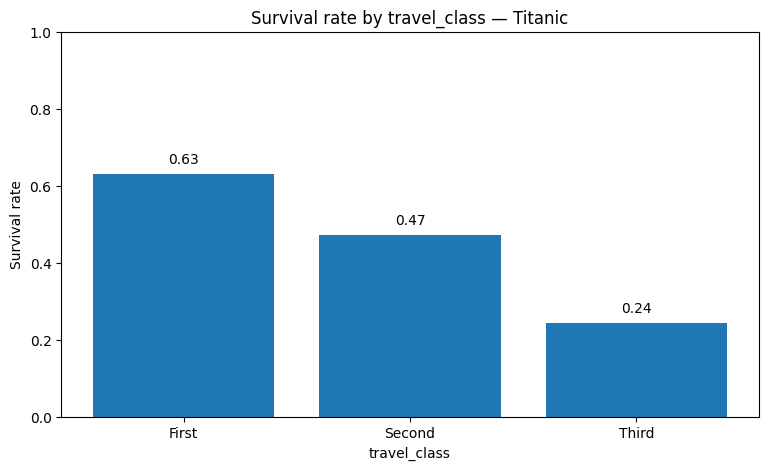

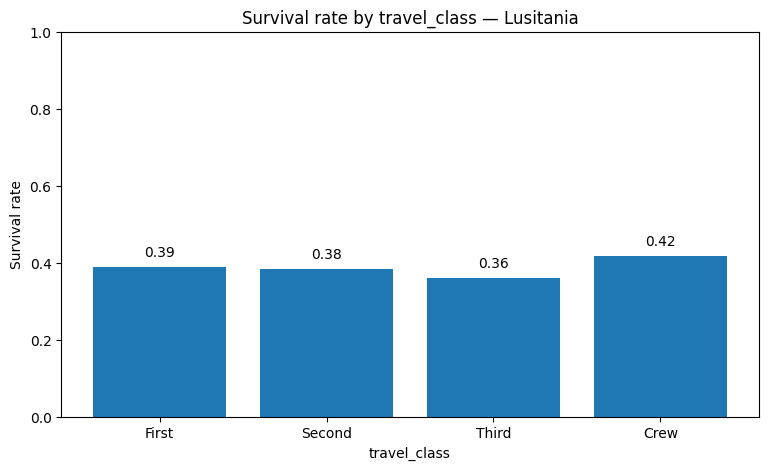

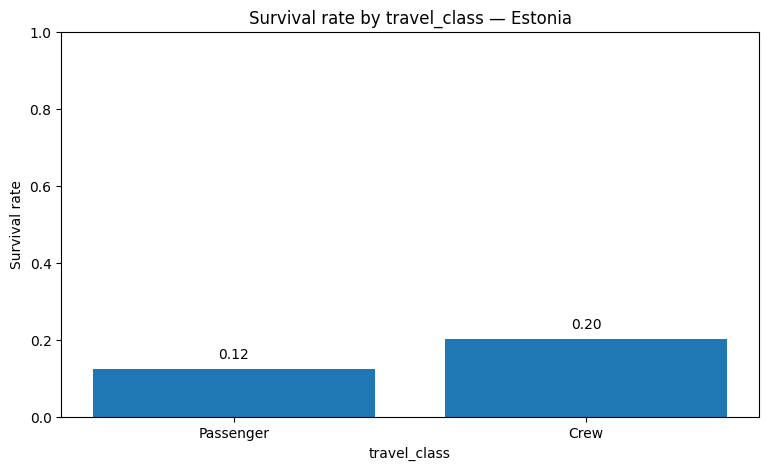

In [20]:
# 3) travel_class -> Survived (par catastrophe)
# Explication: classe sociale / crew = facteur historique majeur.
# =========================
for dis in dfp["disaster"].unique():
    tmp = (
        dfp[dfp["disaster"] == dis]
        .groupby("travel_class")["Survived"]
        .mean()
        .dropna()
    )
    # garder l'ordre logique
    tmp = tmp.reindex([c for c in travel_order if c in tmp.index])

    plt.figure(figsize=(9,5))
    bars = plt.bar(tmp.index.astype(str), tmp.values)
    plt.title(f"Survival rate by travel_class — {dis}")
    plt.xlabel("travel_class")
    plt.ylabel("Survival rate")
    plt.ylim(0,1)
    for b in bars:
        h = b.get_height()
        plt.text(b.get_x() + b.get_width()/2, h + 0.02, f"{h:.2f}", ha="center", va="bottom")
    plt.show()

### Distribution des âges

Cet histogramme présente la distribution des âges des passagers pour l’ensemble des catastrophes. Il permet de comprendre la structure démographique du dataset et d’identifier si certaines tragédies concernaient des populations plus jeunes ou plus âgées. L’âge peut influencer la vulnérabilité physique et donc les chances de survie.

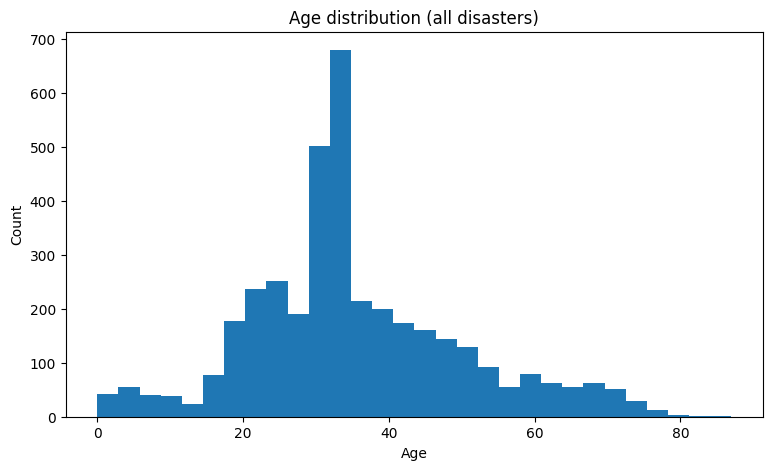

In [21]:
# 4) Age distribution + Age vs Survived
# Explication:
# - histogramme pour voir la distribution
# - puis survie par 'age_group' (bins)
# =========================
plt.figure(figsize=(9,5))
plt.hist(dfp["Age"].dropna(), bins=30)
plt.title("Age distribution (all disasters)")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


### Taux de survie par groupe d’âge

Cette figure compare les probabilités de survie selon des catégories d’âge prédéfinies. Les enfants ont pu bénéficier d’une priorité lors de l’évacuation, tandis que les personnes âgées pouvaient rencontrer des limitations physiques. L’analyse met en évidence d’éventuelles différences liées à l’âge dans la gestion de l’évacuation.

In [ ]:
# 4) Age distribution + Age vs Survived
# Explication:
# - histogramme pour voir la distribution
# - puis survie par 'age_group' (bins)
# =========================
plt.figure(figsize=(9,5))
plt.hist(dfp["Age"].dropna(), bins=30)
plt.title("Age distribution (all disasters)")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


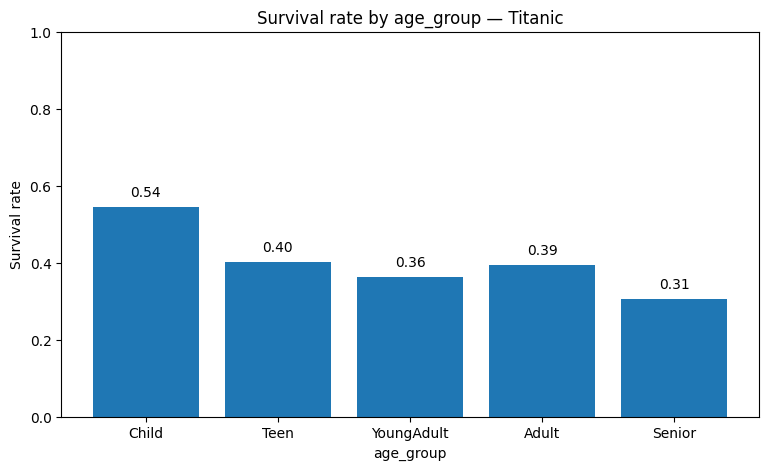

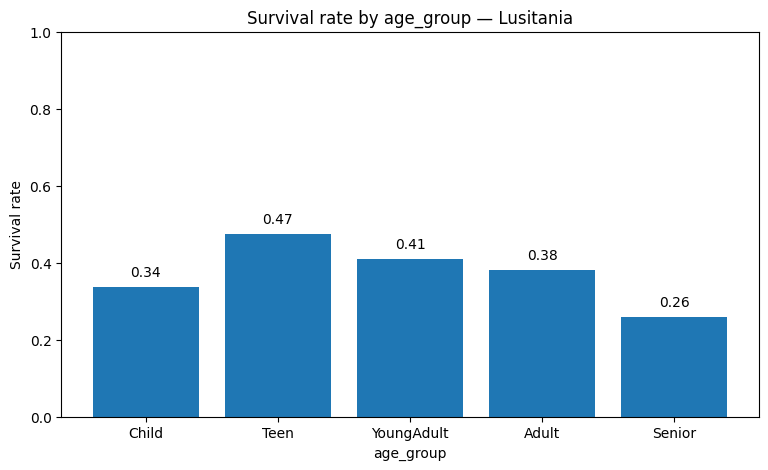

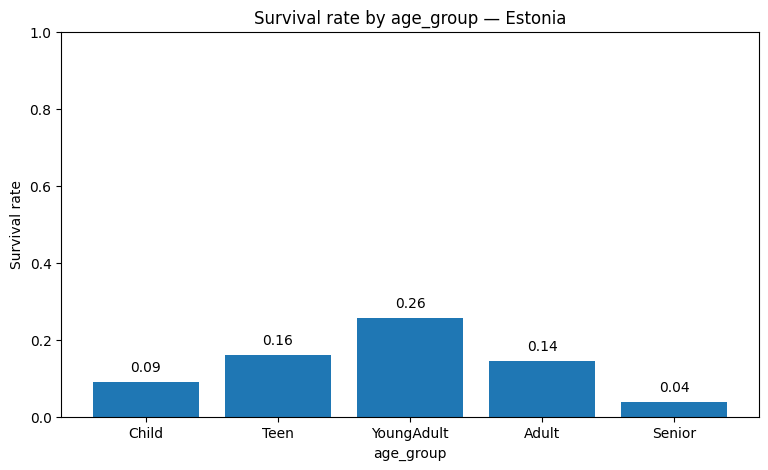

In [22]:
for dis in dfp["disaster"].unique():
    tmp = (
        dfp[dfp["disaster"] == dis]
        .groupby("age_group")["Survived"]
        .mean()
        .dropna()
    )
    # ordre si possible
    tmp = tmp.reindex([c for c in age_order if c in tmp.index])

    plt.figure(figsize=(9,5))
    bars = plt.bar(tmp.index.astype(str), tmp.values)
    plt.title(f"Survival rate by age_group — {dis}")
    plt.xlabel("age_group")
    plt.ylabel("Survival rate")
    plt.ylim(0,1)
    for b in bars:
        h = b.get_height()
        plt.text(b.get_x() + b.get_width()/2, h + 0.02, f"{h:.2f}", ha="center", va="bottom")
    plt.show()

### Taux de survie selon la présence en groupe

Ce graphique examine si le fait de voyager seul ou en groupe influence les chances de survie. Les dynamiques de groupe peuvent affecter la prise de décision, la rapidité de déplacement et l’assistance mutuelle. Les différences observées permettent d’évaluer l’impact des interactions sociales lors des situations d’urgence.(c'est interprétable uniquement pour le titanic)

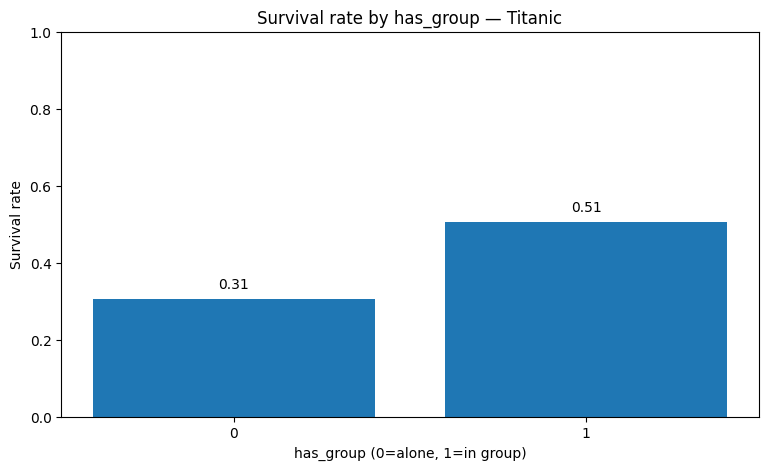

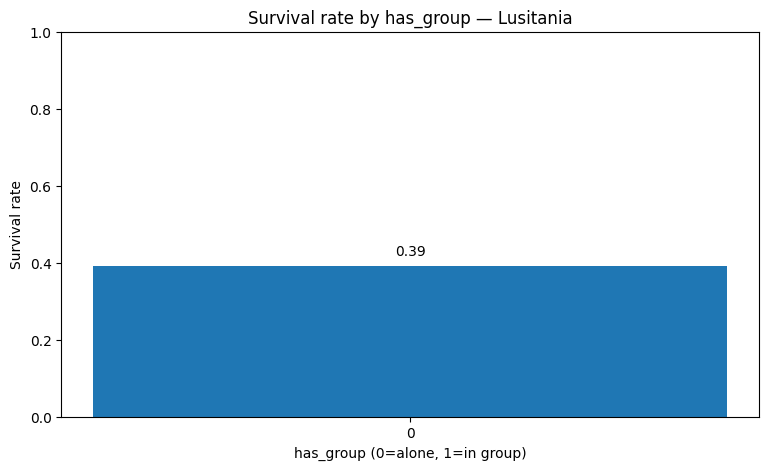

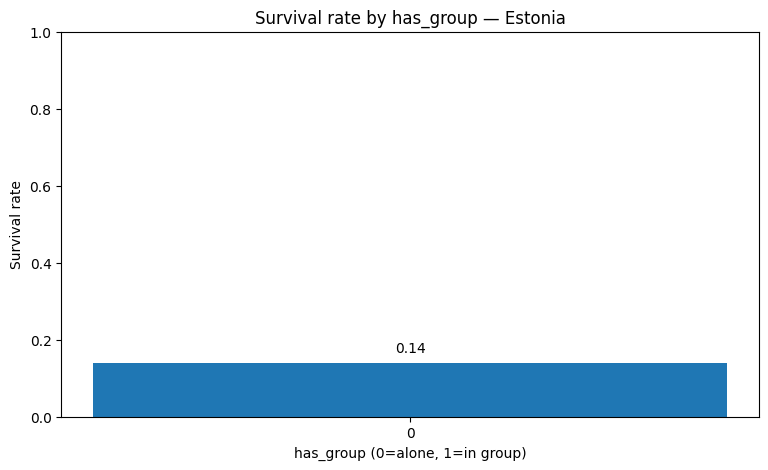

In [24]:
# 5) Group effects: has_group + group_size
# Explication:
# - has_group: seul vs en groupe
# - group_size: on "bin" pour éviter trop de bruit
# =========================
for dis in dfp["disaster"].unique():
    tmp = (
        dfp[dfp["disaster"] == dis]
        .groupby("has_group")["Survived"]
        .mean()
    )
    bar_with_labels(
        tmp.index.astype(str),
        tmp.values,
        title=f"Survival rate by has_group — {dis}",
        xlabel="has_group (0=alone, 1=in group)",
        ylabel="Survival rate"
    )

### Taux de survie selon la taille du groupe

Cette figure analyse la variation des probabilités de survie en fonction de la taille du groupe. Les groupes plus importants peuvent rencontrer des difficultés de coordination, tandis que les individus seuls ou en petits groupes peuvent se déplacer plus rapidement. Le regroupement par classes de taille permet une lecture plus claire des tendances. (interprétable uniquement pour le titanic) 

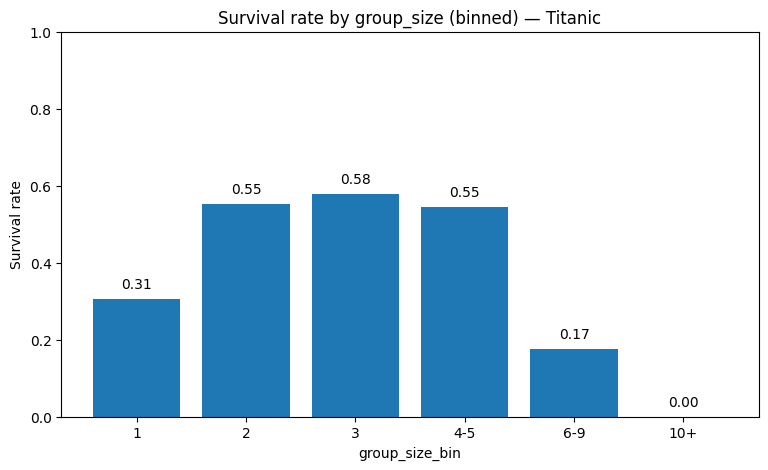

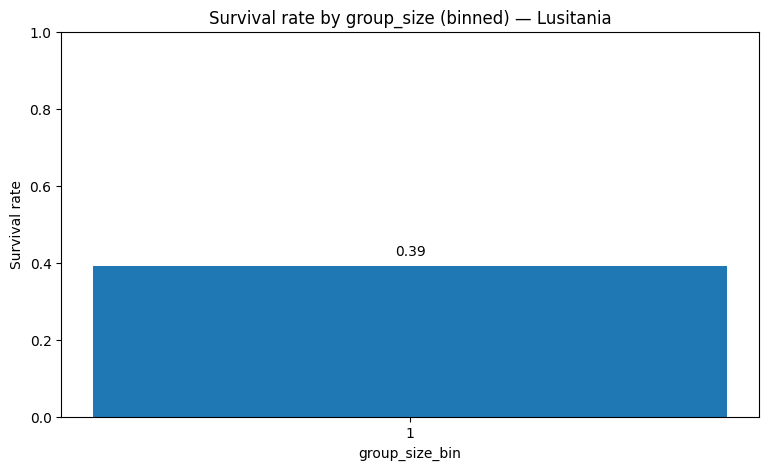

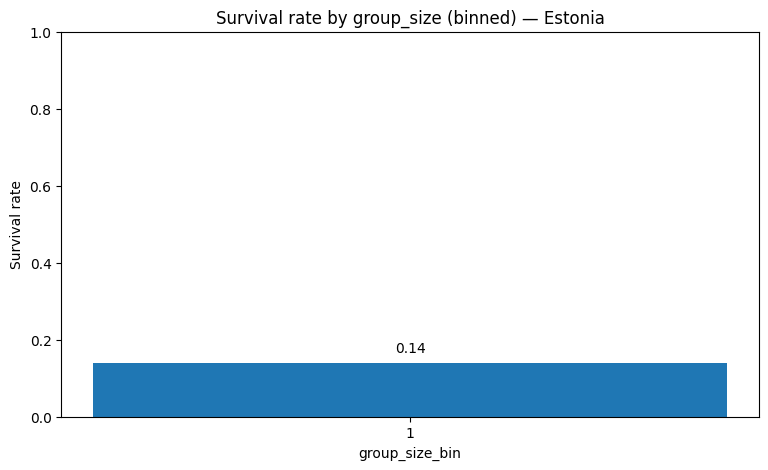

In [25]:
# binning group_size
bins = [1, 2, 3, 4, 6, 10, 1000]
labels = ["1", "2", "3", "4-5", "6-9", "10+"]
dfp["group_size_bin"] = pd.cut(dfp["group_size"], bins=bins, labels=labels, right=False)

for dis in dfp["disaster"].unique():
    tmp = (
        dfp[dfp["disaster"] == dis]
        .groupby("group_size_bin")["Survived"]
        .mean()
        .dropna()
    )
    bar_with_labels(
        tmp.index.astype(str),
        tmp.values,
        title=f"Survival rate by group_size (binned) — {dis}",
        xlabel="group_size_bin",
        ylabel="Survival rate"
    )

### Taux de survie par région de nationalité

Ce graphique compare les probabilités de survie selon les grandes régions de nationalité. Les différences peuvent refléter des inégalités socio-économiques, la localisation des cabines, ou des barrières linguistiques. Toutefois, l’interprétation doit rester prudente, car la nationalité peut être corrélée à d’autres variables structurelles.

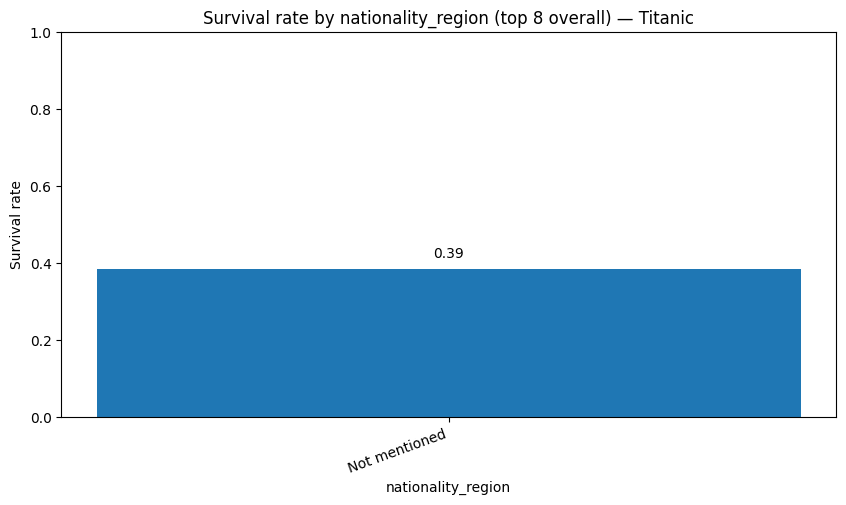

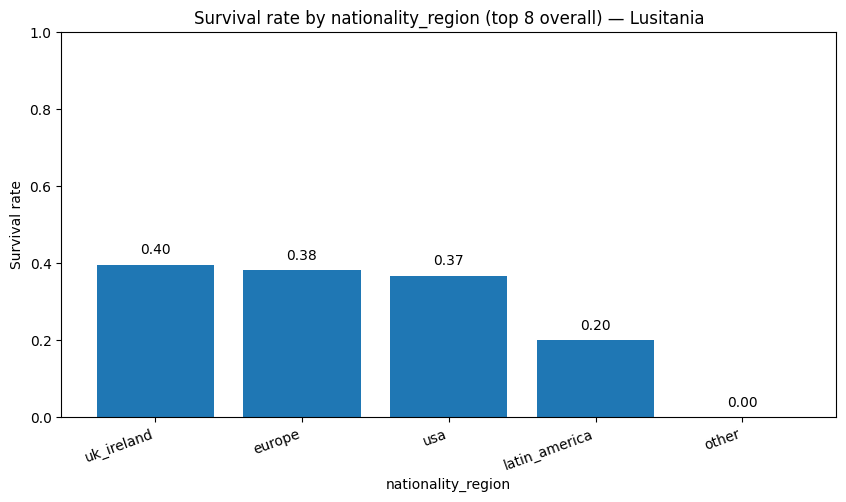

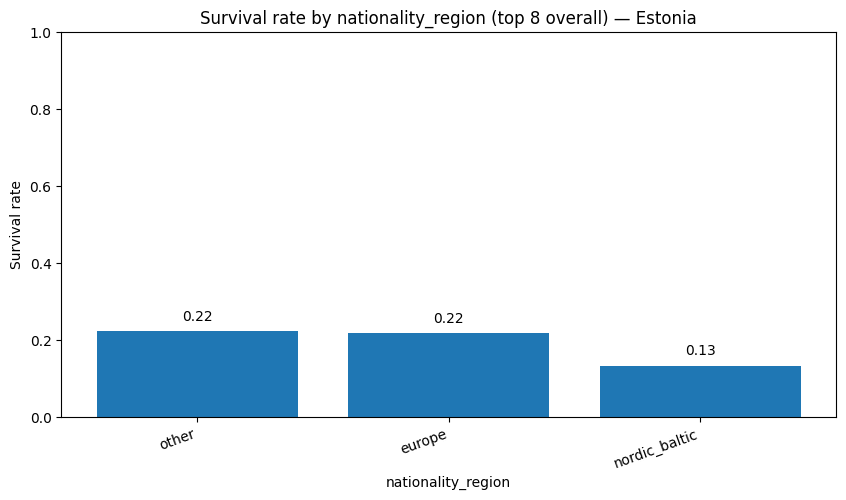

In [26]:
# 6) Nationality region vs Survived (utile surtout Lusitania/Estonia)
# Explication: voir si les régions ont des profils de survie différents.
# On filtre aux régions les plus fréquentes pour éviter un plot illisible.
# =========================
top_regions = dfp["nationality_region"].value_counts().head(8).index
dfp_regions = dfp[dfp["nationality_region"].isin(top_regions)]

for dis in dfp["disaster"].unique():
    tmp = (
        dfp_regions[dfp_regions["disaster"] == dis]
        .groupby("nationality_region")["Survived"]
        .mean()
        .sort_values(ascending=False)
    )
    plt.figure(figsize=(10,5))
    bars = plt.bar(tmp.index.astype(str), tmp.values)
    plt.title(f"Survival rate by nationality_region (top 8 overall) — {dis}")
    plt.xlabel("nationality_region")
    plt.ylabel("Survival rate")
    plt.ylim(0,1)
    plt.xticks(rotation=20, ha="right")
    for b in bars:
        h = b.get_height()
        plt.text(b.get_x() + b.get_width()/2, h + 0.02, f"{h:.2f}", ha="center", va="bottom")
    plt.show()

### Carte thermique du taux de survie (Catastrophe × Classe)

Cette heatmap met en évidence l’influence conjointe de la catastrophe et de la classe de voyage sur la probabilité de survie. Plusieurs tendances importantes apparaissent clairement.

Sur le Titanic, la hiérarchie sociale est extrêmement marquée : les passagers de première classe présentent un taux de survie très élevé (63 %), suivi de la deuxième classe (47 %), tandis que la troisième classe chute fortement à 24 %. Cette forte stratification suggère que l’accès aux canots de sauvetage dépendait fortement du statut socio-économique et de la localisation dans le navire.

Pour le Lusitania, les écarts entre classes sont beaucoup moins prononcés : les taux de survie des trois classes passagers sont relativement proches (entre 36 % et 39 %). En revanche, l’équipage présente le taux de survie le plus élevé (42 %), ce qui peut s’expliquer par leur connaissance du navire et des procédures d’urgence.

L’Estonia montre un schéma très différent : les passagers ont un taux de survie très faible (12 %), légèrement inférieur à celui de l’équipage (20 %). L’absence de classes sociales distinctes et le très faible taux global de survie suggèrent une évacuation extrêmement rapide et chaotique, laissant peu de marge d’action aux passagers.

Globalement, cette figure confirme que la survie n’était pas aléatoire : elle dépendait fortement du contexte de la catastrophe et du rôle occupé à bord. Le Titanic reflète une forte stratification sociale, tandis que les catastrophes plus récentes semblent davantage influencées par des facteurs opérationnels et contextuels.

travel_class,First,Second,Third,Passenger,Crew
disaster,,,,,
Estonia,NaN,NaN,NaN,0.123116,0.202073
Lusitania,0.389655,0.382696,0.361186,NaN,0.415954
Titanic,0.629630,0.472826,0.244353,NaN,NaN


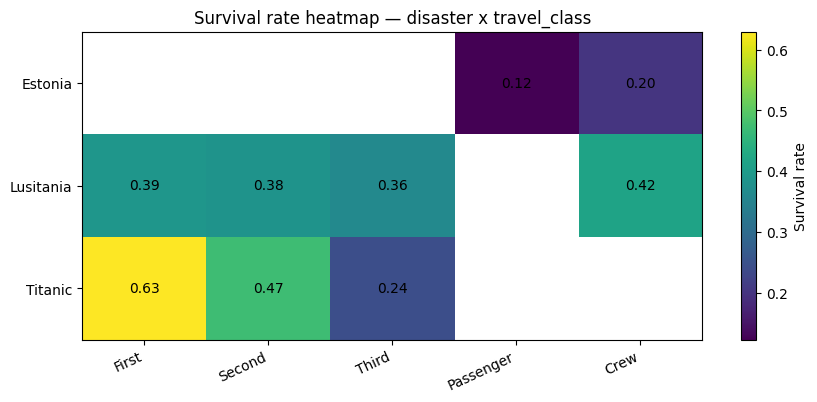

In [27]:
# 7) Viz "pro" finale: matrice (disaster x travel_class) du taux de survie
# Explication: pivot table = table de survie moyenne.
# On l'affiche en "heatmap" avec matplotlib (sans seaborn).
# =========================
pivot = (
    dfp.pivot_table(index="disaster", columns="travel_class", values="Survived", aggfunc="mean")
       .reindex(columns=[c for c in travel_order if c in dfp["travel_class"].cat.categories])
)
display(pivot)

plt.figure(figsize=(10,4))
mat = pivot.values
plt.imshow(mat, aspect="auto")
plt.xticks(range(len(pivot.columns)), pivot.columns.astype(str), rotation=25, ha="right")
plt.yticks(range(len(pivot.index)), pivot.index.astype(str))
plt.title("Survival rate heatmap — disaster x travel_class")
plt.colorbar(label="Survival rate")

for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        val = mat[i, j]
        if np.isfinite(val):
            plt.text(j, i, f"{val:.2f}", ha="center", va="center")
plt.show()

### Tarif du billet et survie

Ce graphique compare le tarif médian payé par les survivants et les non-survivants. Le prix du billet constitue un indicateur indirect du statut socio-économique et de la localisation à bord. Un tarif plus élevé peut être associé à un meilleur accès aux canots de sauvetage et à des conditions plus favorables lors de l’évacuation.

Survived,0,1
disaster,,
Titanic,10.5,26.0


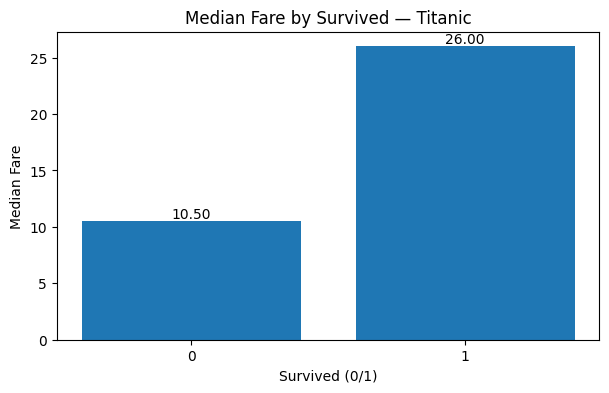

In [28]:
# 8) Bonus: comparer "Fare vs Survived" (Titanic surtout)
# Explication: on compare médianes Fare des survivants vs non-survivants.
# (Fare est souvent NaN pour Estonia/Lusitania selon ton exemple)
# =========================
dfp_fare = dfp.dropna(subset=["Fare"])
if len(dfp_fare) > 0:
    fare_summary = (
        dfp_fare.groupby(["disaster","Survived"])["Fare"]
                .median()
                .unstack("Survived")
    )
    display(fare_summary)

    for dis in dfp_fare["disaster"].unique():
        tmp = dfp_fare[dfp_fare["disaster"] == dis].groupby("Survived")["Fare"].median()
        plt.figure(figsize=(7,4))
        bars = plt.bar(tmp.index.astype(str), tmp.values)
        plt.title(f"Median Fare by Survived — {dis}")
        plt.xlabel("Survived (0/1)")
        plt.ylabel("Median Fare")
        for b in bars:
            h = b.get_height()
            plt.text(b.get_x() + b.get_width()/2, h, f"{h:.2f}", ha="center", va="bottom")
        plt.show()

Dans l’ensemble, ces visualisations suggèrent que la survie n’était pas aléatoire, mais fortement structurée par des facteurs sociaux, démographiques et contextuels propres à chaque catastrophe.